## 가설 2
서울 외곽(관문도시)역은 아침 승차 비율이 높고, 도심 핵심 업무지역은 아침 하차 비율이 높다.

### 분석 대상

**서울 외곽(관문도시)**  
사당, 도봉, 온수, 수색, 신내, 개화, 신정, 석수, 수서, 강일, 양재, 구파발

**도심 핵심 업무지**  
강남·삼성(GBD), 여의도·국회의사당(YBD), 광화문·을지로(CBD)

**분석 시간대**: 출근 시간(7시 ~ 9시)

### 활용 데이터
서울시 지하철 호선별 역별 시간대별 승하차 인원 정보

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

df_raw = pd.read_csv(r"C:\Users\win\Desktop\고급\서울시_지하철_전처리.csv", parse_dates=['날짜'])

def setting_styles_basic():
    rcParams['font.family'] = 'Malgun Gothic'
    rcParams['axes.unicode_minus'] = False

setting_styles_basic()

In [7]:
suburbs_stations = ['사당', '도봉', '온수', '수색', '신내', '개화', '신정', '석수', '수서', '강일', '양재', '구파발']
CBD_stations     = ['강남', '삼성(무역센터)', '여의도', '국회의사당', '광화문(세종문화회관)', '을지로입구']

df_suburbs = df_raw[df_raw['지하철역'].isin(suburbs_stations)].copy()
df_suburbs['지역구분'] = '서울 외곽(관문도시)'

df_cbd = df_raw[df_raw['지하철역'].isin(CBD_stations)].copy()
df_cbd['지역구분'] = '도심 핵심 업무지'

df = pd.concat([df_suburbs, df_cbd], ignore_index=True)

# 출근 시간대 필터 (7시 ~ 9시)
df_rush = df[(df['시작시'] >= 7) & (df['시작시'] < 9)]

# 역별지역구분별 집계
df_result = (
    df_rush
    .groupby(['지하철역', '지역구분'], as_index=False)
    [['승차인원', '하차인원']]
    .sum()
)
df_result['출근_총승하차']   = df_result['승차인원'] + df_result['하차인원']
df_result['승차비율(%)'] = df_result['승차인원'] / df_result['출근_총승하차'] * 100
df_result['하차비율(%)'] = df_result['하차인원'] / df_result['출근_총승하차'] * 100

# 지역구분으로 정렬 
df_result = df_result.sort_values(['지역구분', '지하철역'], ascending=[False, True]).reset_index(drop=True)
print(df_result[['지하철역', '지역구분', '승차비율(%)', '하차비율(%)']].to_string(index=False))

       지하철역        지역구분   승차비율(%)   하차비율(%)
         강일 서울 외곽(관문도시) 78.389795 21.610205
         개화 서울 외곽(관문도시) 82.397236 17.602764
        구파발 서울 외곽(관문도시) 77.529631 22.470369
         도봉 서울 외곽(관문도시) 72.958446 27.041554
         사당 서울 외곽(관문도시) 64.003511 35.996489
         석수 서울 외곽(관문도시) 71.916439 28.083561
         수색 서울 외곽(관문도시) 32.708148 67.291852
         수서 서울 외곽(관문도시) 49.024016 50.975984
         신내 서울 외곽(관문도시) 54.529441 45.470559
         신정 서울 외곽(관문도시) 86.520462 13.479538
         양재 서울 외곽(관문도시) 19.610893 80.389107
         온수 서울 외곽(관문도시) 71.829794 28.170206
         강남   도심 핵심 업무지 18.634209 81.365791
광화문(세종문화회관)   도심 핵심 업무지  6.133590 93.866410
      국회의사당   도심 핵심 업무지  5.474381 94.525619
   삼성(무역센터)   도심 핵심 업무지  7.858123 92.141877
        여의도   도심 핵심 업무지  6.721014 93.278986
      을지로입구   도심 핵심 업무지  5.395452 94.604548


---
##  역별 출근시간 승하차 비율 비교 

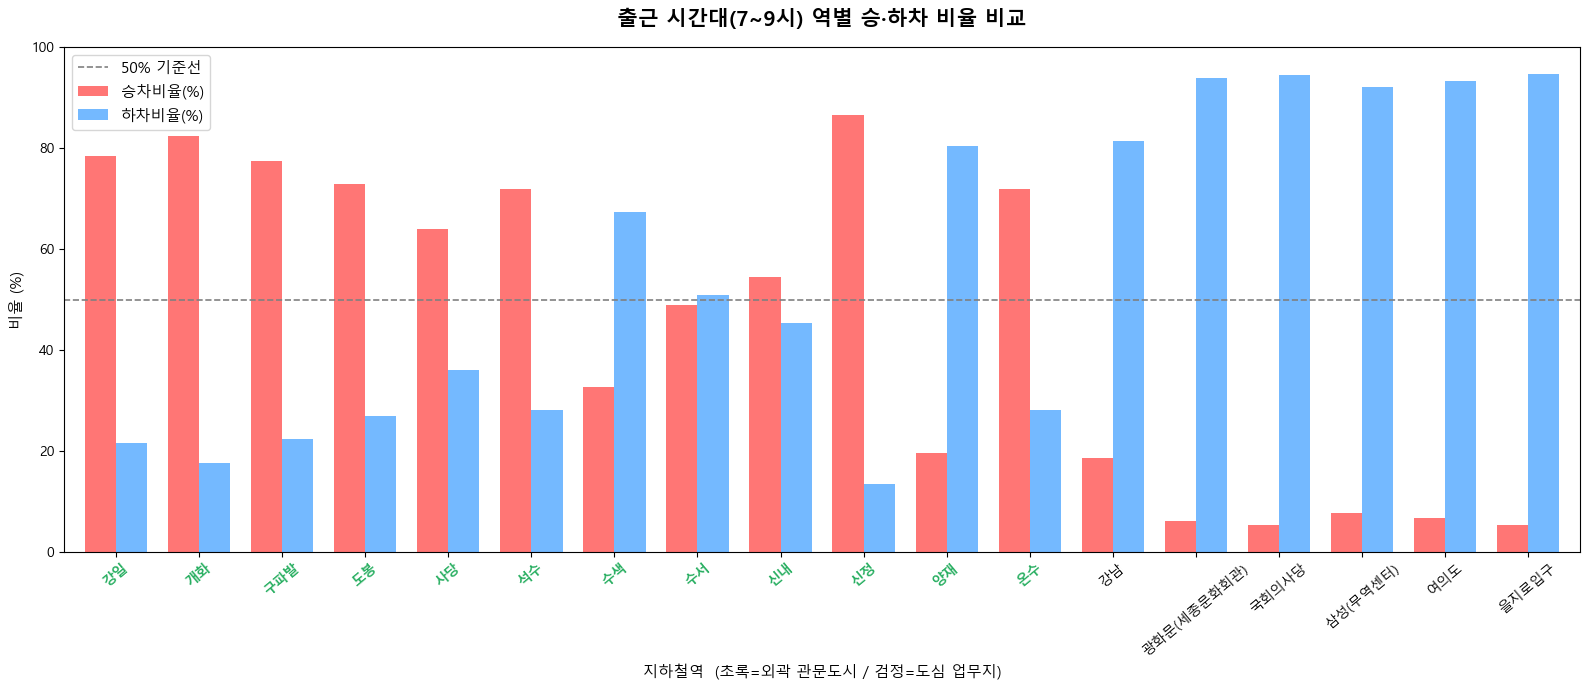

In [8]:
setting_styles_basic()

df_plot = df_result.set_index('지하철역')[['승차비율(%)', '하차비율(%)']]

fig, ax = plt.subplots(figsize=(16, 7))
df_plot.plot(kind='bar', ax=ax, color=['#ff7675', '#74b9ff'], width=0.75)

# X축 레이블 색상: 외곽=초록, 도심=검정
for label in ax.get_xticklabels():
    station_name = label.get_text()
    zone = df_result.loc[df_result['지하철역'] == station_name, '지역구분'].values
    if len(zone) > 0 and zone[0] == '서울 외곽(관문도시)':
        label.set_color('#27ae60')
        label.set_fontweight('bold')
    else:
        label.set_color('black')

# 50% 기준선
ax.axhline(50, color='gray', linestyle='--', linewidth=1.2, label='50% 기준선')

ax.set_title('출근 시간대(7~9시) 역별 승·하차 비율 비교', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('지하철역  (초록=외곽 관문도시 / 검정=도심 업무지)', fontsize=11)
ax.set_ylabel('비율 (%)', fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

 
- 외곽 관문도시(초록): 대부분 역(수서역, 수색역, 양재역 제외)에서 **승차 비율 > 하차 비율** → 이른 아침 시내 방향 출발이 집중
- 도심 핵심 업무지(검정): 하차 비율 > 승차 비율 → 출근 시간대 도심 도착 수요가 집중

---
지역구분별 승하차 비율 

[지역구분별 출근시간 평균 승·하차 비율]
             승차비율(%)  하차비율(%)
지역구분                         
도심 핵심 업무지        8.4     91.6
서울 외곽(관문도시)     63.5     36.5


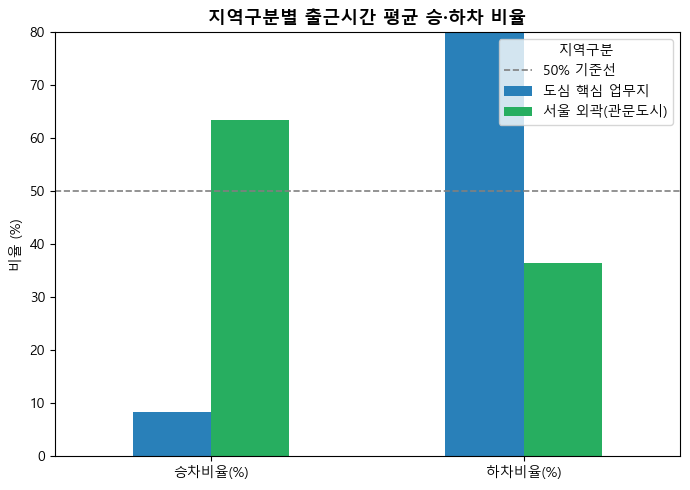

In [9]:

# 지역구분별 평균 비율
summary = df_result.groupby('지역구분')[['승차비율(%)', '하차비율(%)']].mean().round(1)
print('[지역구분별 출근시간 평균 승·하차 비율]')
print(summary)

fig, ax = plt.subplots(figsize=(7, 5))
summary.T.plot(
    kind='bar',
    ax=ax,
    color={
        '서울 외곽(관문도시)': '#27ae60',
        '도심 핵심 업무지':    '#2980b9'
    }
)
ax.axhline(50, color='gray', linestyle='--', linewidth=1.2, label='50% 기준선')
ax.set_title('지역구분별 출근시간 평균 승·하차 비율', fontsize=13, fontweight='bold')
ax.set_ylabel('비율 (%)')
ax.set_xticklabels(['승차비율(%)', '하차비율(%)'], rotation=0)
ax.set_ylim(0, 80)
ax.legend(title='지역구분')
plt.tight_layout()
plt.show()

#### 지역구분별 출근시간 평균 승·하차 비율 해석 ####
도심 핵심 업무지구의 출근 시간대 평균 하차 비율은 91.6%에 달하는 반면 승차 비율은 8.4%에 불과하다. 서울 외곽 관문도시 역의 경우 평균 승차 비율이 63.5%로 하차 비율(36.5%)보다 높아, 두 지역 유형 간 승하차 패턴의 비대칭성이 뚜렷하게 확인된다.

---
출근 시간대 승·하차 패턴이 시간에 따라 어떻게 변화하는지 확인

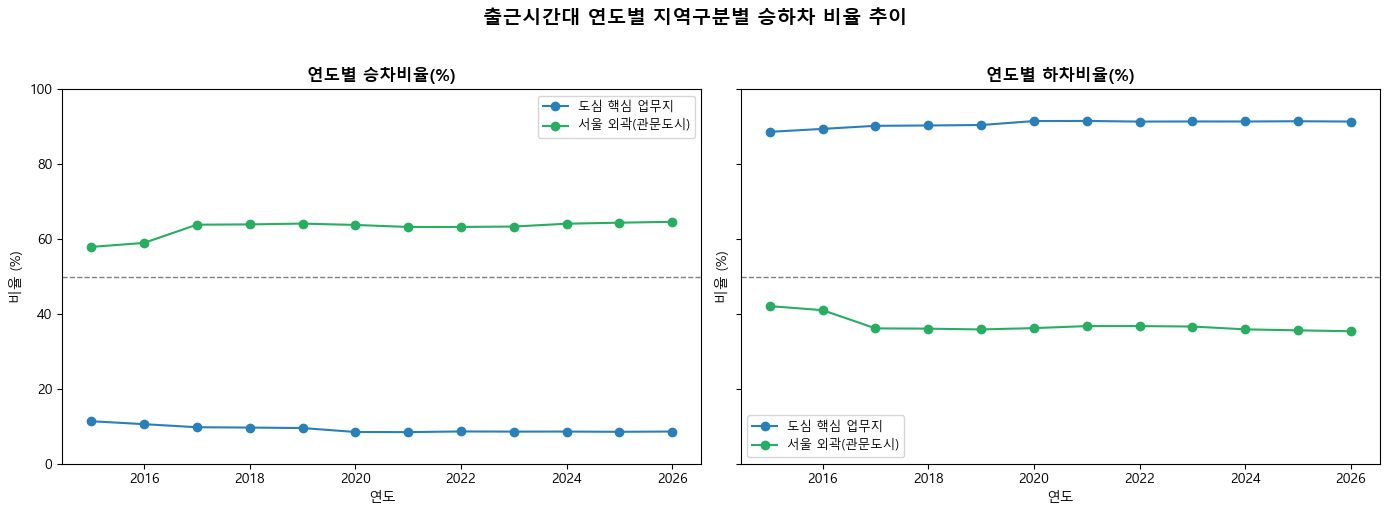

In [10]:
setting_styles_basic()

# 연도별지역구분별 집계
df_yearly = (
    df_rush
    .groupby(['연도', '지역구분'], as_index=False)
    [['승차인원', '하차인원']]
    .sum()
)
df_yearly['총승하차'] = df_yearly['승차인원'] + df_yearly['하차인원']
df_yearly['승차비율(%)'] = df_yearly['승차인원'] / df_yearly['총승하차'] * 100
df_yearly['하차비율(%)'] = df_yearly['하차인원'] / df_yearly['총승하차'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, metric in zip(axes, ['승차비율(%)', '하차비율(%)']):
    for zone, grp in df_yearly.groupby('지역구분'):
        color = '#27ae60' if zone == '서울 외곽(관문도시)' else '#2980b9'
        ax.plot(grp['연도'], grp[metric], marker='o', label=zone, color=color)
    ax.axhline(50, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'연도별 {metric}', fontsize=12, fontweight='bold')
    ax.set_xlabel('연도')
    ax.set_ylabel('비율 (%)')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 100)

plt.suptitle('출근시간대 연도별 지역구분별 승하차 비율 추이', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 연도별 지역구분별 승·하차 비율 추이 ####
 2026년까지 두 지역 유형의 패턴 격차는 일관되게 유지되었다. 이는 서울의 직주분리 구조가 약 10년간 구조적으로 고착되어 있음을 의미하며, 특정 연도의 일시적 현상이 아닌 구조적 패턴임을 뒷받침한다. 외곽 역의 승차 비율과 도심 역의 하차 비율 모두 연도별로 큰 변동 없이 유사한 수준을 유지하고 있다.

---
## 결론

| 구분 | 출근시간 승차 비율 | 출근시간 하차 비율 | 비고 |
|------|---|---|---|
| 서울 외곽 관문도시 | 높음 | 낮음 | 아침에 시내로 출발 |
| 도심 핵심 업무지 | 낮음 | 높음 | 아침에 도심으로 도착 |



> 외곽 관문도시 역에서는 출근 시간 승차 비율이 하차 비율보다 높고, 도심 업무지 역에서는 반대 패턴이 뚜렷하게 나타난다.  
> 단, 수서역, 수색역, 양재역은 예외적으로 도심과 가까운 외곽 역의 특성을 지닌다.